# Introduction to Video Understanding

## Instrucciones Generales

El siguiente práctico se puede realizar de manera **individual**. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Todas las preguntas deben ser respondida en celdas de texto. No se aceptará el _output_ de una celda de código como respuesta.

**Nombre:** COMPLETAR

**Fecha de entrega: 24 Agosto 2025**

El siguiente práctico cuanta con 2 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

**Importante.** Para facilitar su ejecución, cada sección puede ser ejecutada independientemente.

Se recomienda **fuertemente** revisar las secciones donde se entrega código porque algunas actividades de código pueden reutilizar el mismo código pero con cambios en algunas líneas.

## 1. Utilities

Essential libraries for executing this tutorial.

In [1]:
!pip install imageio-ffmpeg

In [2]:
import os, cv2
from tqdm.notebook import tqdm
import re
import math
import numpy as np
import torch.utils.data as data
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import time
import copy
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
import torchvision

# from tensorflow_docs.vis import embed
# from moviepy.editor import *

## 2. Dataset

### Download data

We will use the [UCF11 dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) consisting of YouTube videos containing 11 action categories. For this tutorial, the dataset is hosted in a repository that we own.

In [3]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar

--2026-04-27 00:18:24--  https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1045106394 (997M) [application/x-rar-compressed]
Saving to: ‘UCF11_updated_mpg.rar’

UCF11_updated_mpg.r 100%[===================>] 996.69M  14.7MB/s    in 73s     

2026-04-27 00:19:38 (13.6 MB/s) - ‘UCF11_updated_mpg.rar’ saved [1045106394/1045106394]



In [4]:
!unrar x '/content/UCF11_updated_mpg.rar'


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/UCF11_updated_mpg.rar

Creating    UCF11_updated_mpg                                         OK
Creating    UCF11_updated_mpg/basketball                              OK
Creating    UCF11_updated_mpg/basketball/v_shooting_01                OK
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_01.mpg       0%  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_02.mpg       0%  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_03.mpg       0%  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_04.mpg       0%  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_05.mpg       0%  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_06.mpg       0%  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooti

### Exploring data

Let's explore the basic statistics of the dataset.

In [5]:
def statistics(path_dataset):
  classes = os.listdir(path_dataset)
  num_classes = len(classes)
  dictionary = {}
  for name in classes:
    num_videos = len(os.listdir("{}/{}".format(path_dataset,name)))-1
    total_videos = len(os.listdir("{}/{}/Annotation".format(path_dataset,name)))
    dictionary[name] = {'unique_videos': num_videos, 'total_videos': total_videos}
  return dictionary

In [6]:
path_dataset = "/content/UCF11_updated_mpg"
out = statistics(path_dataset)
pd.DataFrame.from_dict(out)

,soccer_juggling,walking,golf_swing,diving,volleyball_spiking,tennis_swing,trampoline_jumping,basketball,biking,swing,horse_riding
unique_videos,25,25,25,25,25,25,25,25,25,25,25
total_videos,156,123,142,156,109,167,111,141,144,138,198


### Visualize Videos

Here we can visualize a selected video from the dataset.

In [7]:
path_sample = "/content/UCF11_updated_mpg/basketball/v_shooting_04/v_shooting_04_01.mpg"

In [8]:
import imageio
import os

# load the video file
clip = os.path.abspath(path_sample)

# create a function
def gifMkaker(inputPath, targetFormat, duration):
    # giving a output path
    outputPath = "animation" + targetFormat

    print(f'converting {inputPath} \n to {outputPath}')

    reader = imageio.get_reader(inputPath)
    # define fps of the gif
    # The keyword `fps` is no longer supported.
    # Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50)
    fps = reader.get_meta_data()['duration']

    writer = imageio.get_writer(outputPath, duration=fps)

    for i, frames in enumerate(reader):
        writer.append_data(frames)
        # print(f'Frame{frames}')
        if i > duration:
          break
    print('done')
    writer.close()

gifMkaker(clip, '.gif', 30)

converting /content/UCF11_updated_mpg/basketball/v_shooting_04/v_shooting_04_01.mpg 
 to animation.gif
done


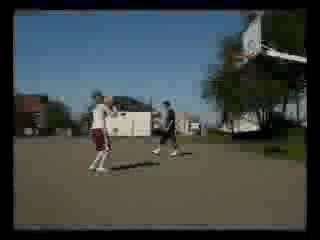

In [9]:
from IPython.display import Image as ImageD
ImageD(filename="animation.gif")

### Preprocess data

Here we have two main functions for preprocess the videos.

The `vids_to_frames` function convert from video in mpg formart to N frames in jpg format.

In [10]:
def vids_to_frames(path_videos, action, path):
    path_action = os.path.join(path_videos, action)
    list_cams = os.listdir(path_action)
    for cam in list_cams:
        path_cam_save = os.path.join(path, cam.split('.')[0])
        os.mkdir(path_cam_save)
        vid_path = os.path.join(path_action, cam)
        vidcap = cv2.VideoCapture(vid_path)
        success,image = vidcap.read()
        count = 0
        while success:
            path_cam_frame = os.path.join(path_cam_save, f'frame_{count}.jpg')
            cv2.imwrite(path_cam_frame, image)
            success,image = vidcap.read()
            count += 1

The `preprocess_data` function divides the data into train and val, and separate the videos into frames using the vids_to_frames function.

We need to define the `paths` and `split_size`.

In [11]:
def preprocess_data(path_data, train_path, val_path, split_size):
    if not os.path.exists(train_path) and not os.path.exists(val_path):
        os.mkdir(train_path)
        os.mkdir(val_path)
        list_classes = os.listdir(path_data)
        for class_name in tqdm(list_classes):
            train_class = os.path.join(train_path, class_name)
            os.mkdir(train_class)
            val_class = os.path.join(val_path, class_name)
            os.mkdir(val_class)
            path_videos = os.path.join(path_data, class_name)
            list_actions = os.listdir(path_videos)
            list_actions = [a for a in list_actions if a != 'Annotation']
            num_actions = len(list_actions)
            num_actions_train = int(num_actions*split_size)
            action_train = list_actions[:num_actions_train]
            action_test = list_actions[num_actions_train:]
            for action in list_actions:
                if action in action_train:
                    vids_to_frames(path_videos, action, train_class)
                else:
                    vids_to_frames(path_videos, action, val_class)

Defining the paths to training data and validation data. Then we preprocess the whole dataset with `split_size=0.8`

In [12]:
path_data = '/content/UCF11_updated_mpg'
train_path = '/content/train'
val_path = '/content/val'

In [13]:
preprocess_data(path_data, train_path, val_path, 0.8) # it takes about ~4min

  0%|          | 0/11 [00:00<?, ?it/s]

### Video dataset

Now, we will create our dataset for UCF11 dataset.



This is the Dataset Class created to transform and load the videos into the model using uniform temporal sampling. Note that `np.linspace` function allows to do that.

<figure>
<center>
<img src='https://www.sharpsightlabs.com/wp-content/uploads/2018/10/visual-representation-of-np-linspace-0-100-5.png' width="500" />
</center>
</figure>

In [14]:
class VideoDataset(data.Dataset):

    def __init__(self, path_data, num_frames, transform=None):
        # This code loads all the videos and prepares the labels.
        self.list_classes = os.listdir(path_data)
        self.list_data = []
        self.list_labels = []
        for idx, c in enumerate(self.list_classes):
            path_class_data = os.path.join(path_data, c)
            class_data = os.listdir(path_class_data)
            self.list_data.extend(class_data)
            self.list_labels.extend([idx]*len(class_data))
        self.root_dir = path_data
        self.transform = transform
        self.num_frames = num_frames

    def __len__(self):
        # The number of all videos in the set
        return len(self.list_data)

    def natural_keys(self, text):
        return int(re.split(r'(\d+)', text)[1])

    def __getitem__(self, idx):
        # function to get the item or video i
        elem = self.list_data[idx]
        label = self.list_labels[idx]
        path_elem = os.path.join(self.root_dir, self.list_classes[label], elem)
        frames_elem = os.listdir(path_elem)
        frames_elem.sort(key=self.natural_keys)
        idx_frames = np.linspace(0, len(frames_elem)-1, num=self.num_frames, dtype = int)
        list_frames = []
        for ind_frame in idx_frames:
            frame_name = frames_elem[ind_frame]
            img_name = os.path.join(path_elem, frame_name)
            frame = Image.open(img_name).convert('RGB')
            list_frames.append(frame)
        process_data = self.transform(list_frames)
        return process_data, label

### Video transformation

These classes and functions are used to augment the video data, which is essential to train the model and avoid overfitting.

In [15]:
class GroupRandomHorizontalFlip(object):
    """Randomly horizontally flips the given PIL.Image with a probability of 0.5
    """
    def __init__(self, is_flow=False):
        self.is_flow = is_flow

    def __call__(self, img_group, is_flow=False):
        v = random.random()
        if v < 0.5:
            ret = [img.transpose(Image.FLIP_LEFT_RIGHT) for img in img_group]
            if self.is_flow:
                for i in range(0, len(ret), 2):
                    ret[i] = ImageOps.invert(ret[i])  # invert flow pixel values when flipping
            return ret
        else:
            return img_group

In [16]:
class GroupMultiScaleCrop(object):

    def __init__(self, input_size, scales=None, max_distort=1, fix_crop=True, more_fix_crop=True):
        self.scales = scales if scales is not None else [1, .875, .75, .66]
        self.max_distort = max_distort
        self.fix_crop = fix_crop
        self.more_fix_crop = more_fix_crop
        self.input_size = input_size if not isinstance(input_size, int) else [input_size, input_size]
        self.interpolation = Image.BILINEAR

    def __call__(self, img_group):

        im_size = img_group[0].size

        crop_w, crop_h, offset_w, offset_h = self._sample_crop_size(im_size)
        crop_img_group = [img.crop((offset_w, offset_h, offset_w + crop_w, offset_h + crop_h)) for img in img_group]
        ret_img_group = [img.resize((self.input_size[0], self.input_size[1]), self.interpolation)
                         for img in crop_img_group]
        return ret_img_group

    def _sample_crop_size(self, im_size):
        image_w, image_h = im_size[0], im_size[1]

        # find a crop size
        base_size = min(image_w, image_h)
        crop_sizes = [int(base_size * x) for x in self.scales]
        crop_h = [self.input_size[1] if abs(x - self.input_size[1]) < 3 else x for x in crop_sizes]
        crop_w = [self.input_size[0] if abs(x - self.input_size[0]) < 3 else x for x in crop_sizes]

        pairs = []
        for i, h in enumerate(crop_h):
            for j, w in enumerate(crop_w):
                if abs(i - j) <= self.max_distort:
                    pairs.append((w, h))

        crop_pair = random.choice(pairs)
        if not self.fix_crop:
            w_offset = random.randint(0, image_w - crop_pair[0])
            h_offset = random.randint(0, image_h - crop_pair[1])
        else:
            w_offset, h_offset = self._sample_fix_offset(image_w, image_h, crop_pair[0], crop_pair[1])

        return crop_pair[0], crop_pair[1], w_offset, h_offset

    def _sample_fix_offset(self, image_w, image_h, crop_w, crop_h):
        offsets = self.fill_fix_offset(self.more_fix_crop, image_w, image_h, crop_w, crop_h)
        return random.choice(offsets)

    @staticmethod
    def fill_fix_offset(more_fix_crop, image_w, image_h, crop_w, crop_h):
        w_step = (image_w - crop_w) // 4
        h_step = (image_h - crop_h) // 4

        ret = list()
        ret.append((0, 0))  # upper left
        ret.append((4 * w_step, 0))  # upper right
        ret.append((0, 4 * h_step))  # lower left
        ret.append((4 * w_step, 4 * h_step))  # lower right
        ret.append((2 * w_step, 2 * h_step))  # center

        if more_fix_crop:
            ret.append((0, 2 * h_step))  # center left
            ret.append((4 * w_step, 2 * h_step))  # center right
            ret.append((2 * w_step, 4 * h_step))  # lower center
            ret.append((2 * w_step, 0 * h_step))  # upper center

            ret.append((1 * w_step, 1 * h_step))  # upper left quarter
            ret.append((3 * w_step, 1 * h_step))  # upper right quarter
            ret.append((1 * w_step, 3 * h_step))  # lower left quarter
            ret.append((3 * w_step, 3 * h_step))  # lower righ quarter

        return ret

In [17]:
class GroupScale(object):
    """ Rescales the input PIL.Image to the given 'size'.
    'size' will be the size of the smaller edge.
    For example, if height > width, then image will be
    rescaled to (size * height / width, size)
    size: size of the smaller edge
    interpolation: Default: PIL.Image.BILINEAR
    """

    def __init__(self, size, interpolation=Image.BILINEAR):
        self.worker = torchvision.transforms.Scale(size, interpolation)

    def __call__(self, img_group):
        return [self.worker(img) for img in img_group]


class GroupCenterCrop(object):
    def __init__(self, size):
        self.worker = torchvision.transforms.CenterCrop(size)

    def __call__(self, img_group):
        return [self.worker(img) for img in img_group]


class Stack(object):

    def __init__(self, roll=False):
        self.roll = roll

    def __call__(self, img_group):
        if img_group[0].mode == 'L':
            return np.concatenate([np.expand_dims(x, 2) for x in img_group], axis=2)
        elif img_group[0].mode == 'RGB':
            if self.roll:
                return np.concatenate([np.array(x)[:, :, ::-1] for x in img_group], axis=2)
            else:
                return np.concatenate(img_group, axis=2)


class ToTorchFormatTensor(object):
    """ Converts a PIL.Image (RGB) or numpy.ndarray (H x W x C) in the range [0, 255]
    to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0] """

    def __init__(self, div=True):
        self.div = div

    def __call__(self, pic):
        if isinstance(pic, np.ndarray):
            # handle numpy array
            img = torch.from_numpy(pic).permute(2, 0, 1).contiguous()
        else:
            # handle PIL Image
            img = torch.ByteTensor(torch.ByteStorage.from_buffer(pic.tobytes()))
            img = img.view(pic.size[1], pic.size[0], len(pic.mode))
            # put it from HWC to CHW format
            # yikes, this transpose takes 80% of the loading time/CPU
            img = img.transpose(0, 1).transpose(0, 2).contiguous()
        return img.float().div(255) if self.div else img.float()


class GroupNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        rep_mean = self.mean * (tensor.size()[0] // len(self.mean))
        rep_std = self.std * (tensor.size()[0] // len(self.std))

        # TODO: make efficient
        for t, m, s in zip(tensor, rep_mean, rep_std):
            t.sub_(m).div_(s)

        return tensor


def get_transform():
    cropping = torchvision.transforms.Compose([
        GroupScale(256),
        GroupCenterCrop(224),
    ])
    transform = torchvision.transforms.Compose([
        cropping,
        Stack(roll=False),
        ToTorchFormatTensor(div=True),
        GroupNormalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return transform

def scale_size(input_size):
    return input_size * 256 // 224

## 3. Dataloader

### Instance transformation

Instantiate the transformations for training and validation.
It is necessary to define a fixed `input_size`, and normalization parameters (`input_mean` and `input_std`).

In [18]:
# size of frame
input_size = 224
# normalization
input_mean = [0.485, 0.456, 0.406]
input_std = [0.229, 0.224, 0.225]
# backbone name
arch = "Resnet"

In [19]:
transform_train = torchvision.transforms.Compose([
                                                  GroupMultiScaleCrop(input_size, [1, .875, .75, .66]),
                                                  GroupRandomHorizontalFlip(is_flow=False),
                                                  Stack(roll=(arch in ['BNInception', 'InceptionV3'])),
                                                  ToTorchFormatTensor(div=(arch not in ['BNInception', 'InceptionV3'])),
                                                  GroupNormalize(input_mean, input_std)
                                                  ])

In [20]:
transform_val = torchvision.transforms.Compose([
                       GroupCenterCrop(input_size),
                       Stack(roll=(arch in ['BNInception', 'InceptionV3'])),
                       ToTorchFormatTensor(div=(arch not in ['BNInception', 'InceptionV3'])),
                       GroupNormalize(input_mean, input_std)
                   ])

### Instance video dataset

Instantiate the VideoDataset for training and validation with 8 frames per video

In [21]:
num_frames = 5

In [22]:
dataset_train = VideoDataset('/content/train', num_frames, transform_train)
dataset_val = VideoDataset('/content/val', num_frames, transform_val)

## 4. Create model

This is the model used to classify the videos. It is based on a pre-trained ResNet-34 backbone and avg pooling to reduce the temporal dimension.

We are going to build the two versions we explored in class. `VideoCNN`, which is a model based solely on CNN without temporal processing, and `VideoRNN`, which is a model based on CNN and RNN to process visual and temporal information.

In [23]:
class VideoCNN(nn.Module):
    def __init__(self, num_classes, num_frames=8):
        super(VideoCNN, self).__init__()
        # create a pre-trained cnn
        self.net = models.resnet34(pretrained=True)
        # create a classifier
        self.fc = nn.Linear(in_features=self.net.fc.in_features,
                            out_features=num_classes)
        self.net.fc = nn.Identity()
        self.num_segments = num_frames

    def forward(self, inputs):
        # flatten input
        inputs = inputs.view((-1, 3) + inputs.size()[-2:])
        # compute frames representation with cnn
        out = self.net(inputs)
        # unflatten output of cnn
        out = out.view((-1, self.num_segments) + out.size()[1:])
        # average pooling of representations
        out = torch.mean(out, dim = 1)
        # classify
        out = self.fc(out)
        return out

In [24]:
class VideoRNN(nn.Module):
    def __init__(self, num_classes, num_frames=8):
        super(VideoRNN, self).__init__()
        # create a pre-trained cnn
        self.net = models.resnet34(pretrained=True)
        # create a rnn (1 layer)
        self.rnn = nn.GRU(input_size=self.net.fc.in_features,
                          hidden_size=self.net.fc.in_features,
                          num_layers=1,
                          batch_first=True)
        self.dropout= nn.Dropout(0.1)
        # create a classifier
        self.fc = nn.Linear(in_features=self.net.fc.in_features,
                            out_features=num_classes)
        self.net.fc = nn.Identity()
        self.num_segments = num_frames

    def forward(self, inputs):
        # flatten input
        inputs = inputs.view((-1, 3) + inputs.size()[-2:])
        # compute representation with cnn
        out = self.net(inputs)
        # unflatten output of cnn
        out = out.view((-1, self.num_segments) + out.size()[1:])
        # processing frames representations with rnn
        bz, seq, dim = out.shape
        h0 = torch.randn(1, bz, dim, device=inputs.device)
        out, hn = self.rnn(out, h0)
        # classify using the last frame representation
        out = self.dropout(out[:,-1])
        out = self.fc(out)
        return out

### Instance model

Instantiate the model. We can decide to use `VideoCNN` or `VideoRNN`.

In [25]:
num_classes = len(dataset_train.list_classes)
model_type = "cnn+rnn"

if model_type == "cnn+rnn":
  model = VideoRNN(num_classes, num_frames)
elif model_type == "cnn":
  model = VideoCNN(num_classes, num_frames)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 135MB/s]


## 5. Train the model

Train the model during 12 epoch

In [26]:
num_epochs = 3

In [27]:
device = torch.device("cuda")
model = model.to(device)

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [29]:
batch_size = 40

trainloader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

dataloaders={'train': trainloader, 'val':testloader}
dataset_sizes = {'train': len(dataset_train), 'val': len(dataset_val)}

In [30]:
def train_model(model, criterion, optimizer, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    dict_acc = {'train': [], 'val': []}
    dict_loss = {'train': [], 'val': []}
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0
            num_elem = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    preds = torch.argmax(outputs, dim = 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                num_elem += inputs.size(0)
            # if phase == 'train':
            #     scheduler.step()

            epoch_loss = running_loss / num_elem
            epoch_acc = running_corrects.double() / num_elem

            dict_acc[phase].append(epoch_acc)
            dict_loss[phase].append(epoch_loss)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, dict_acc, dict_loss

In [31]:
model, dict_acc, dict_loss = train_model(model, criterion, optimizer, num_epochs=num_epochs)

Epoch 0/2
----------
train Loss: 2.2411 Acc: 0.2734
val Loss: 2.0130 Acc: 0.4557

Epoch 1/2
----------
train Loss: 1.8069 Acc: 0.5911
val Loss: 1.5673 Acc: 0.5506

Epoch 2/2
----------
train Loss: 1.3081 Acc: 0.7227
val Loss: 1.1362 Acc: 0.6899

Training complete in 2m 51s
Best val Acc: 0.689873


## 6. Train Graphs

In [32]:
def parse_data(data):
    new_data = []
    for d in data:
        new_data.append(d.item())
    return new_data

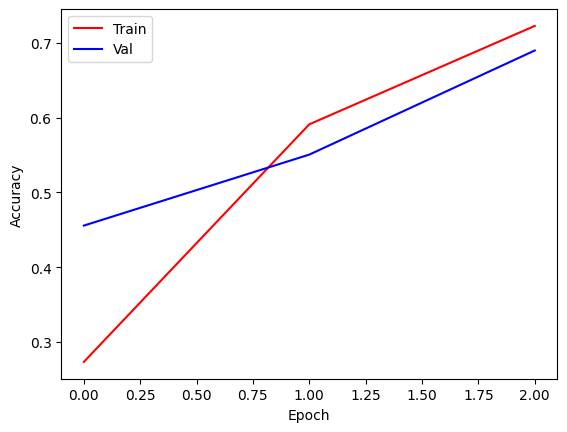

In [33]:
epochs = list(range(num_epochs))
plt.plot(epochs, parse_data(dict_acc['train']), 'r', label='Train')
plt.plot(epochs, parse_data(dict_acc['val']), 'b', label='Val')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 7. Positive and Negative examples

In [34]:
def getInferenceModel(model, testloader):
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim = 1)
        break
    return preds, inputs, labels

In [35]:
def plot_example(dataset, idx, pred):

    fig=plt.figure(figsize=(20, 8))
    columns = 4
    rows = 2
    elem = dataset.list_data[idx]
    label = dataset.list_labels[idx]
    fig.suptitle('GT: {}, P: {}'.format(dataset.list_classes[label], dataset.list_classes[pred]), fontsize=16)
    path_elem = os.path.join(dataset.root_dir, dataset.list_classes[label], elem)
    frames_elem = os.listdir(path_elem)
    frames_elem.sort(key=dataset.natural_keys)
    idx_frames = np.linspace(0, len(frames_elem)-1, num=dataset.num_frames, dtype = int)
    list_frames = []
    for i, ind_frame in enumerate(idx_frames):
        frame_name = frames_elem[ind_frame]
        img_name = os.path.join(path_elem, frame_name)
        frame = Image.open(img_name).convert('RGB')
        ax = fig.add_subplot(rows, columns, i+1)
        ax.set_title("t = {}".format(ind_frame))
        ax.axis('off')
        plt.imshow(frame)

In [36]:
model.eval()
testloader = torch.utils.data.DataLoader(dataset_val, batch_size=30, shuffle=False)

In [37]:
preds, inputs, labels = getInferenceModel(model, testloader)

In [38]:
torch.cuda.empty_cache()

In [39]:
good_examples = np.where((preds == labels).cpu() == True)[0]
good_examples

array([11, 12, 13, 19, 20, 22, 23, 28])

In [40]:
bad_examples = np.where((preds != labels).cpu() == True)[0]
bad_examples

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 14, 15, 16, 17, 18, 21,
       24, 25, 26, 27, 29])

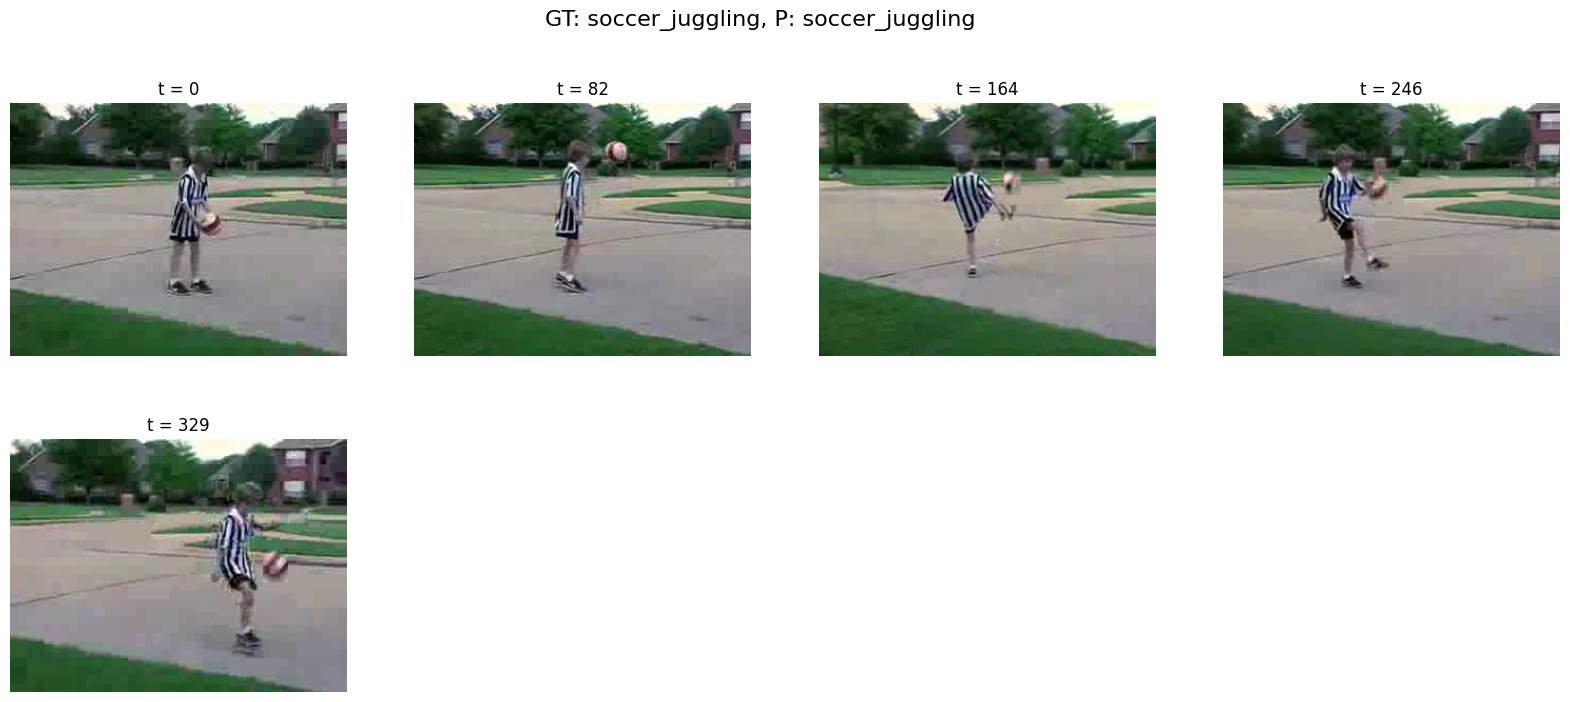

In [41]:
idx = good_examples[-1]
plot_example(dataset_val, idx, preds[idx])

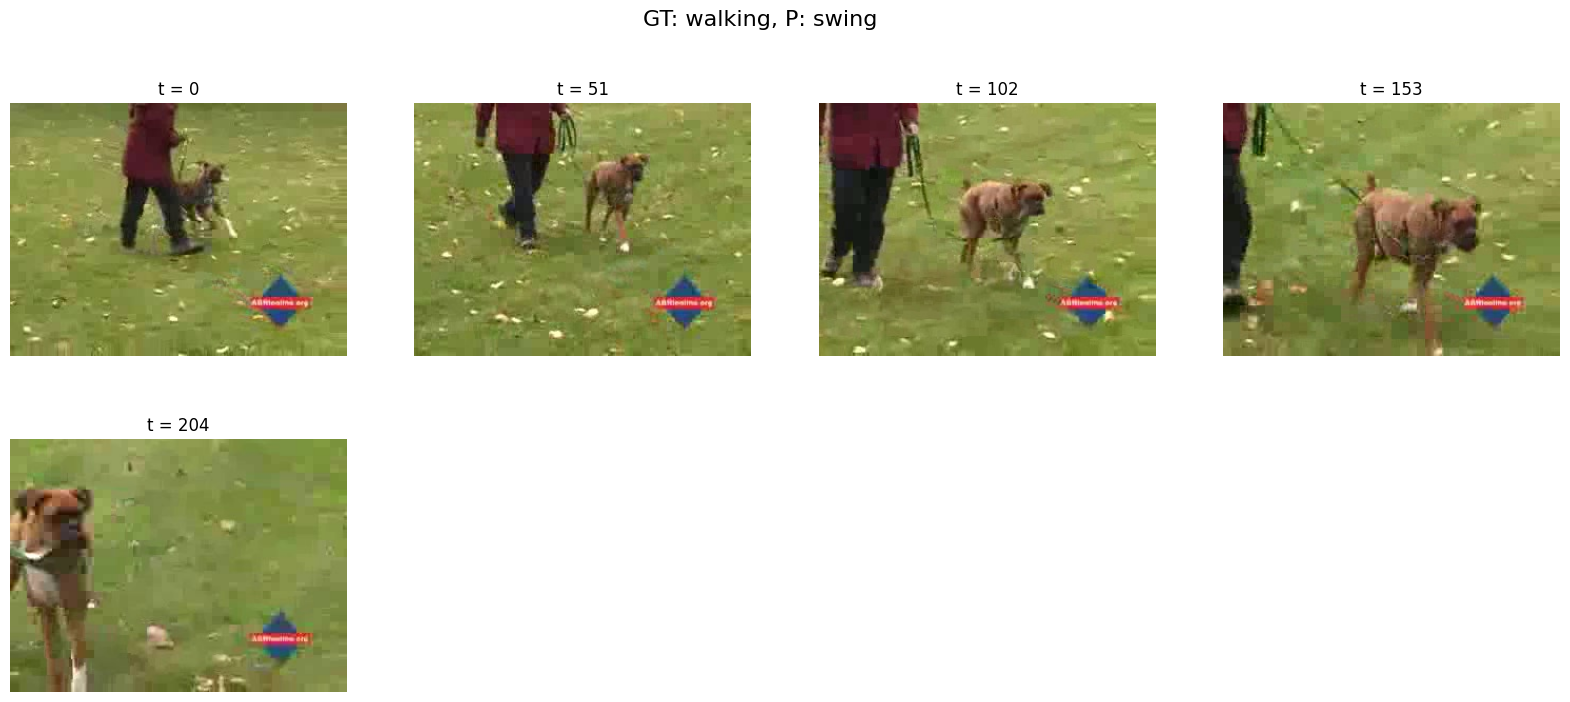

In [42]:
idx = bad_examples[-1]
plot_example(dataset_val, idx, preds[idx])

## 8. Activity


In this section, you will be asked about the topics studied in the theoretical and practical class.

1. What are the main challenges of video analysis?

**Respuesta:**

El análisis de video presenta varios desafíos importantes en comparación con el análisis de imágenes estáticas:

1. **Alta dimensionalidad:** Un video es básicamente una secuencia de imágenes (frames) en el tiempo. Esto significa que los datos son mucho más grandes y costosos de procesar que una sola imagen. Por ejemplo, un video de 10 segundos a 30 fps tiene 300 imágenes.

2. **Dependencias temporales:** Las acciones ocurren a lo largo del tiempo, por lo que el modelo necesita entender no solo *qué* aparece en un frame, sino también *cómo* cambia entre frames. Por ejemplo, para saber si alguien está "saltando" hay que ver múltiples frames en secuencia.

3. **Variabilidad visual:** El mismo tipo de acción puede verse muy diferente dependiendo del ángulo de la cámara, la iluminación, la velocidad del movimiento, la ropa de las personas, el fondo del video, etc.

4. **Costo computacional:** Procesar videos requiere mucha memoria RAM y GPU, ya que hay que manejar datos en 4 dimensiones (batch, tiempo, ancho, alto) en lugar de 3 (batch, ancho, alto).

5. **Falta de datos etiquetados:** Etiquetar videos es mucho más costoso que etiquetar imágenes, porque requiere revisar secuencias completas.

6. **Movimiento de cámara:** La cámara misma puede moverse, lo cual genera movimiento "falso" que no corresponde a la acción que se quiere detectar.

7. **Oclusión:** Los objetos o personas pueden quedar tapados parcialmente por otros elementos durante el video.

2. Why is video analysis important?

**Respuesta:**

El análisis de video es importante porque permite a las computadoras "entender" lo que sucede en una secuencia de imágenes. Hay muchas aplicaciones prácticas:

1. **Seguridad y vigilancia:** Detectar automáticamente comportamientos sospechosos o situaciones de peligro en cámaras de seguridad, sin necesitar un humano mirando cada pantalla 24/7.

2. **Deportes y entretenimiento:** Analizar movimientos de jugadores, contar goles, detectar infracciones (por ejemplo, el VAR en fútbol), o generar estadísticas automáticamente.

3. **Medicina y salud:** Monitorear pacientes en hospitales, detectar caídas en adultos mayores, analizar movimientos en fisioterapia o diagnosticar enfermedades neurológicas a través del análisis del movimiento.

4. **Vehículos autónomos:** Los autos sin conductor necesitan entender en tiempo real lo que sucede a su alrededor: peatones caminando, otros vehículos, señales de tráfico, etc.

5. **Interacción Humano-Computadora:** Controlar dispositivos con gestos (como los comandos de manos en Smart TVs), o interfaces que responden a lenguaje de señas.

6. **Contenido digital y redes sociales:** Clasificar y recomendar videos automáticamente (como hace YouTube), moderar contenido inapropiado, o generar subtítulos automáticos.

En resumen, el análisis de video permite automatizar tareas que antes requerían observación humana constante, haciéndolas más rápidas, escalables y menos costosas.

3. What is action classification?

**Respuesta:**

La **clasificación de acciones** (action classification) es una tarea de visión por computadora que consiste en **asignar una etiqueta o categoría a un video completo** en función de la acción o actividad que se está realizando en él.

**¿Cómo funciona?**
- Se toma un video como entrada (o una secuencia de frames).
- El modelo analiza la información visual y temporal del video.
- El modelo produce como salida una clase o etiqueta. Por ejemplo: "baloncesto", "natación", "saltar", "correr".

**Ejemplo concreto:**
En este laboratorio usamos el dataset UCF11, que tiene 11 categorías de acciones (basketball, biking, diving, golf swinging, horse riding, soccer juggling, swinging, tennis swinging, trampoline jumping, volleyball spiking, walking with a dog). El modelo recibe un video y tiene que predecir cuál de estas 11 acciones está ocurriendo.

**Diferencia con detección de acciones:**
- La *clasificación* asume que el video completo contiene una sola acción dominante y asigna una única etiqueta.
- La *detección* de acciones también localiza *dónde* (en qué parte del video) ocurre cada acción, lo cual es más complejo.

En resumen, la clasificación de acciones es como la clasificación de imágenes pero aplicada a videos: en lugar de decir "esta imagen contiene un gato", decimos "este video contiene una persona jugando basketball".

4. Mention and describe the temporal sampling used in this tutorial

**Respuesta:**

El muestreo temporal utilizado en este tutorial es el **Muestreo Temporal Uniforme** (Uniform Temporal Sampling).

**¿Qué hace?**
En lugar de usar todos los frames de un video (que pueden ser cientos o miles), se selecciona una cantidad fija de frames (por ejemplo, `num_frames = 5`) distribuidos de forma *uniforme* a lo largo de toda la duración del video.

**¿Cómo se implementa?**
Esto se logra con la función `np.linspace` en la clase `VideoDataset`:

```python
idx_frames = np.linspace(0, len(frames_elem)-1, num=self.num_frames, dtype=int)
```

- `np.linspace(start, stop, num)` genera `num` valores igualmente espaciados entre `start` y `stop`.
- Por ejemplo, si un video tiene 100 frames y queremos 5, `np.linspace(0, 99, 5)` nos da: `[0, 24, 49, 74, 99]` — es decir, el frame 0, 24, 49, 74 y el último.

**¿Por qué es útil?**
- Captura información de todo el video (inicio, medio y final), evitando quedarse solo con una parte.
- Reduce drásticamente la cantidad de datos a procesar, haciendo el entrenamiento más eficiente.
- Mantiene una representación temporal razonablemente buena con pocos frames.

**Alternativas:**
- **Muestreo aleatorio:** seleccionar frames al azar (útil para augmentation durante entrenamiento).
- **Muestreo denso:** usar todos los frames o muchos frames consecutivos (más informativo pero más costoso).
- **Muestreo por segmentos:** dividir el video en segmentos y tomar un frame de cada uno (similar al uniforme).

5. What is the temporal pooling followed in this lab? What are the problems with it?

**Respuesta:**

**¿Qué temporal pooling se usa en este laboratorio?**

En el modelo `VideoCNN`, se usa **Average Temporal Pooling** (promedio temporal):

```python
# En el método forward() de VideoCNN:
out = torch.mean(out, dim=1)  # <- promedio de todos los frames
```

Esto significa que:
1. Primero, la CNN extrae un vector de características (embedding) para cada frame seleccionado del video.
2. Luego, se calcula el **promedio** de todos esos vectores.
3. Finalmente, ese vector promedio se pasa al clasificador (`fc`) para predecir la acción.

**¿Qué problemas tiene?**

1. **Pierde el orden temporal:** Al promediar, el modelo ya no sabe qué frame vino primero y cuál último. El vector resultante sería el mismo si ordenas los frames de cualquier manera. Por ejemplo, la acción "saltar" tiene fases muy distintas (agacharse, impulso, vuelo, aterrizaje) y el promedio mezcla todo sin distinguirlas.

2. **Pierde la dinámica del movimiento:** El movimiento es información que vive *entre* frames (cómo cambia la imagen). El promedio destruye esa información de cambio.

3. **Representa mal acciones complejas:** Si una acción tiene fases muy distintas (ej. un saque de tenis: preparación → golpe → seguimiento), el promedio produce un "punto medio" que puede no representar bien ninguna fase.

**¿Cómo lo soluciona el modelo VideoRNN?**

El modelo `VideoRNN` usa una red recurrente **GRU** en lugar del promedio:
```python
out, hn = self.rnn(out, h0)  # procesa la secuencia en orden
out = self.fc(out[:,-1])     # usa el último estado oculto
```
La GRU lee los frames en orden y mantiene una "memoria" de lo que vio antes, capturando así la información temporal y la dinámica del movimiento.

6. Train and evaluate the model with 4 frames per video instead of 8 frames. How does the model performance be affected? Note: Use code of section 6 to show the training graph.

In [43]:
# ===========================================================
# ACTIVIDAD 6: Reentrenar el modelo con 4 frames por video
# ===========================================================
# Aquí repetimos el proceso de entrenamiento pero cambiando
# num_frames de 5 (o el valor original) a 4, para ver cómo
# afecta al rendimiento del modelo.

# --- Paso 1: Definir el nuevo número de frames ---
# Usamos 4 frames en lugar de 8 (o 5 del experimento original)
num_frames_4 = 4

# --- Paso 2: Crear los datasets con 4 frames ---
# Reutilizamos las mismas transformaciones (transform_train y transform_val)
# pero creamos nuevos datasets con num_frames_4
dataset_train_4 = VideoDataset('/content/train', num_frames_4, transform_train)
dataset_val_4   = VideoDataset('/content/val',   num_frames_4, transform_val)

print(f"Videos en train: {len(dataset_train_4)}")
print(f"Videos en val:   {len(dataset_val_4)}")

# --- Paso 3: Crear los DataLoaders ---
# El DataLoader se encarga de cargar los datos en lotes (batches)
# durante el entrenamiento
batch_size_4 = 40

trainloader_4 = torch.utils.data.DataLoader(dataset_train_4, batch_size=batch_size_4, shuffle=True)
testloader_4  = torch.utils.data.DataLoader(dataset_val_4,   batch_size=batch_size_4, shuffle=False)

dataloaders_4    = {'train': trainloader_4, 'val': testloader_4}
dataset_sizes_4  = {'train': len(dataset_train_4), 'val': len(dataset_val_4)}

# --- Paso 4: Crear un nuevo modelo con 4 frames ---
# IMPORTANTE: el parámetro num_frames del modelo debe coincidir
# con el num_frames del dataset, porque define cómo se reorganiza
# el tensor internamente.
num_classes_4 = len(dataset_train_4.list_classes)
model_4 = VideoRNN(num_classes_4, num_frames_4)   # usamos VideoRNN igual que antes
model_4 = model_4.to(device)

# --- Paso 5: Definir función de pérdida y optimizador ---
criterion_4 = nn.CrossEntropyLoss()
optimizer_4 = optim.SGD(model_4.parameters(), lr=0.01)

# --- Paso 6: Entrenar el modelo ---
# Usamos el mismo número de épocas para comparar de forma justa
num_epochs_4 = num_epochs   # mismo valor que en el experimento original

# Guardamos los dataloaders y tamaños globalmente para que train_model los use
# (la función train_model usa las variables globales 'dataloaders' y 'dataset_sizes')
dataloaders   = dataloaders_4
dataset_sizes = dataset_sizes_4

print("\nEntrenando modelo con 4 frames por video...")
model_4, dict_acc_4, dict_loss_4 = train_model(model_4, criterion_4, optimizer_4, num_epochs=num_epochs_4)

Videos en train: 1284
Videos en val:   316

Entrenando modelo con 4 frames por video...
Epoch 0/2
----------
train Loss: 2.2842 Acc: 0.2274
val Loss: 2.0695 Acc: 0.3513

Epoch 1/2
----------
train Loss: 1.8604 Acc: 0.5039
val Loss: 1.6187 Acc: 0.5127

Epoch 2/2
----------
train Loss: 1.4251 Acc: 0.6651
val Loss: 1.2641 Acc: 0.6551

Training complete in 2m 17s
Best val Acc: 0.655063


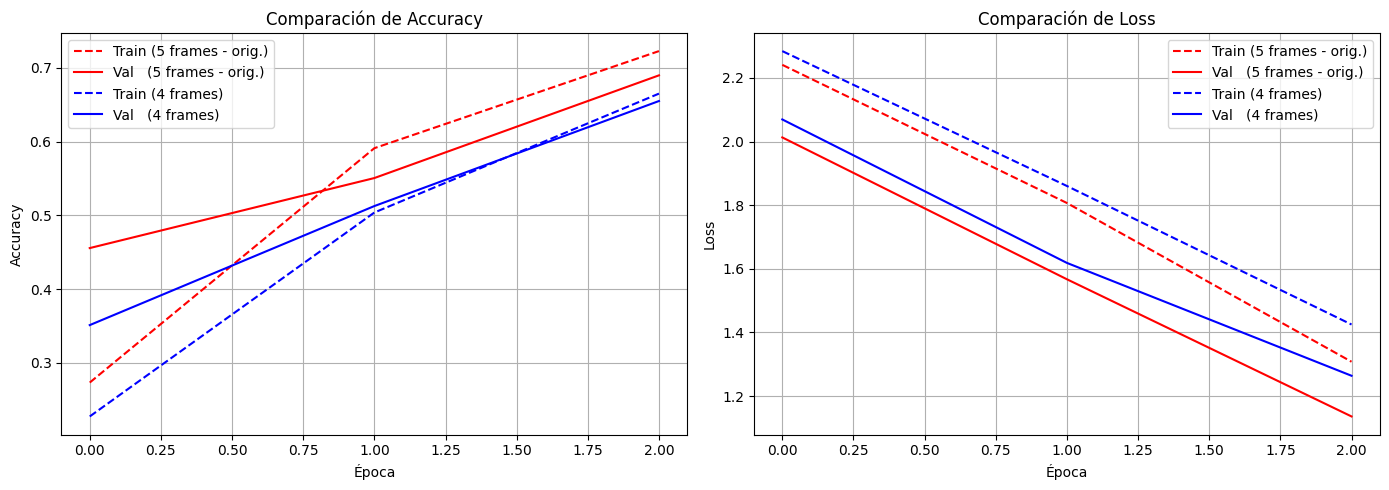


Mejor Val Accuracy (original - 5 frames): 0.6899
Mejor Val Accuracy (4 frames):                       0.6551


In [44]:
# ===========================================================
# Gráfica comparativa: modelo original vs modelo con 4 frames
# ===========================================================
# Visualizamos las curvas de accuracy en validación para comparar
# ambos experimentos de forma clara.

epochs_range = list(range(num_epochs_4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: Accuracy ---
axes[0].plot(epochs_range, parse_data(dict_acc['train']),   'r--', label=f'Train ({num_frames} frames - orig.)')
axes[0].plot(epochs_range, parse_data(dict_acc['val']),     'r-',  label=f'Val   ({num_frames} frames - orig.)')
axes[0].plot(epochs_range, parse_data(dict_acc_4['train']), 'b--', label=f'Train (4 frames)')
axes[0].plot(epochs_range, parse_data(dict_acc_4['val']),   'b-',  label=f'Val   (4 frames)')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Época')
axes[0].set_title('Comparación de Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Gráfica 2: Loss ---
axes[1].plot(epochs_range, dict_loss['train'],   'r--', label=f'Train ({num_frames} frames - orig.)')
axes[1].plot(epochs_range, dict_loss['val'],     'r-',  label=f'Val   ({num_frames} frames - orig.)')
axes[1].plot(epochs_range, dict_loss_4['train'], 'b--', label=f'Train (4 frames)')
axes[1].plot(epochs_range, dict_loss_4['val'],   'b-',  label=f'Val   (4 frames)')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Época')
axes[1].set_title('Comparación de Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Imprimimos el mejor accuracy de validación de cada modelo
best_val_orig = max(parse_data(dict_acc['val']))
best_val_4    = max(parse_data(dict_acc_4['val']))
print(f"\nMejor Val Accuracy (original - {num_frames} frames): {best_val_orig:.4f}")
print(f"Mejor Val Accuracy (4 frames):                       {best_val_4:.4f}")

**Respuesta:**

Al comparar el modelo entrenado con el número de frames original (5) versus el modelo entrenado con 4 frames, se pueden observar los siguientes efectos:

**¿Qué esperamos que ocurra al reducir de 5 a 4 frames?**

1. **Menor información temporal disponible:** Con menos frames, el modelo recibe una "foto" menos completa del video. Hay más riesgo de perderse momentos clave de la acción (por ejemplo, el punto exacto del golpe en tenis).

2. **Posible caída en el accuracy de validación:** En general, con menos frames el modelo tiene menos contexto temporal para tomar su decisión, lo que puede llevar a una peor clasificación, especialmente en acciones que requieren ver la evolución completa (ej. saltar, nadar).

3. **Mayor velocidad de entrenamiento:** Con menos frames por video, cada forward/backward pass requiere menos cómputo, por lo que cada época tarda menos tiempo.

4. **Sin impacto en el modelo base (CNN/RNN):** La arquitectura del modelo en sí no cambia, solo cambia cuántos frames de entrada recibe. El modelo se adapta automáticamente mediante el parámetro `num_frames`.

**Conclusión:**

Existe un trade-off entre:
- **Más frames** → más información temporal → mejor accuracy potencial → más tiempo de cómputo y memoria.
- **Menos frames** → menos información → posible caída de accuracy → entrenamiento más rápido.

La gráfica generada en el código compara visualmente ambos experimentos. Si el accuracy de validación con 4 frames es menor, confirma que la información temporal adicional que proveen más frames es útil para la tarea de clasificación de acciones.

**Nota:** Para tareas muy simples o acciones muy cortas, la diferencia entre 4 y 5 frames puede ser mínima. La diferencia se vuelve más pronunciada al comparar cantidades más distintas (ej. 4 vs 16 frames).